# Peru Fire Data Preparation Pipeline

**Purpose:** Download, extract, and process satellite-derived fire and burned area products for Peru.

**Outputs:**
- `../outputs/Peru_burned_area.shp` — 24-year burned area polygon dataset (2001–2024)
- `../outputs/yearly/` — Individual yearly burned area shapefiles

---

## Data Sources

| Product | Description | Source |
|---------|-------------|--------|
| **MODIS MCD64A1** | Monthly burned area polygons, Collection 6.1 | UMD SFTP (`fuoco.geog.umd.edu`) |
| **Peru Boundary** | Country administrative boundary | SERNANP / MINAM |

**MODIS MCD64A1** is NASA's Terra + Aqua combined burned area product. Each monthly file covers a 10°×10° MODIS tile at 500 m resolution. Tile codes `Win05` and `Win06` together cover mainland Peru.

**Access credentials (public):** `fire` / `burnt`

---

## Pipeline Overview

```
SFTP (UMD server)
    └── .tar.gz archives (Win05 + Win06, monthly, 2001–2024)
           └── Extract shapefiles
                  └── Parse timestamps → year / month
                         └── Merge tiles by year
                                └── Clip to Peru boundary
                                       └── Export analysis-ready shapefiles
```

## 1. Configuration

In [1]:
from pathlib import Path

# --- Paths (adjust if needed) ---
BASE_DIR        = Path("../../docs/gis-project/Peru")
MODIS_DIR       = BASE_DIR / "modis"
BOUNDARY_SHP    = Path("../../docs/gis-project/Peru_project/admin_bnd/peru_country_bnd.shp")
OUTPUT_DIR      = Path("../outputs")
YEARLY_DIR      = OUTPUT_DIR / "yearly"

# --- SFTP credentials (public FIRMS server) ---
SFTP_HOST       = "fuoco.geog.umd.edu"
SFTP_USER       = "fire"
SFTP_PASSWORD   = "burnt"
SFTP_PATHS      = [
    "/data/MODIS/C61/MCD64A1/SHP/Win05/",
    "/data/MODIS/C61/MCD64A1/SHP/Win06/",
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
YEARLY_DIR.mkdir(parents=True, exist_ok=True)
MODIS_DIR.mkdir(parents=True, exist_ok=True)
print("Directories ready.")
print(f"Boundary SHP: {BOUNDARY_SHP.resolve()}")
print(f"Boundary exists: {BOUNDARY_SHP.exists()}")

Directories ready.
Boundary SHP: /Users/bikal/Documents/durupo-project/Peru_Project_2025/docs/gis-project/Peru_project/admin_bnd/peru_country_bnd.shp
Boundary exists: True


## 2. Imports

In [6]:
import os
import glob
import tarfile
import datetime
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import pysftp
    SFTP_AVAILABLE = True
except ImportError:
    SFTP_AVAILABLE = False
    print("pysftp not installed — SFTP download section will be skipped.")
    print("Install with: pip install pysftp")

pysftp not installed — SFTP download section will be skipped.
Install with: pip install pysftp


## 3. Download MODIS MCD64A1 via SFTP

Downloads `.tar.gz` archives from the University of Maryland Global Fire Products server.
Each archive contains monthly burned area shapefiles for one MODIS tile.

> **Skip this cell** if you have already downloaded the data.

In [7]:
def download_modis_sftp(sftp_paths, local_dir, host, user, password):
    """Download all .tar.gz files from the given SFTP paths."""
    if not SFTP_AVAILABLE:
        print("pysftp unavailable — skipping download.")
        return

    cnopts = pysftp.CnOpts()
    cnopts.hostkeys = None  # disable host-key verification for public server

    with pysftp.Connection(host, username=user, password=password, cnopts=cnopts) as sftp:
        for remote_path in sftp_paths:
            tile = remote_path.rstrip("/").split("/")[-1]
            tile_dir = Path(local_dir) / tile
            tile_dir.mkdir(parents=True, exist_ok=True)

            files = sftp.listdir(remote_path)
            tar_files = [f for f in files if f.endswith(".tar.gz")]
            print(f"[{tile}] Found {len(tar_files)} archives.")

            for fname in tar_files:
                dest = tile_dir / fname
                if dest.exists():
                    continue  # already downloaded
                sftp.get(remote_path + fname, str(dest))
                print(f"  Downloaded: {fname}")

# Uncomment to run:
# download_modis_sftp(SFTP_PATHS, MODIS_DIR, SFTP_HOST, SFTP_USER, SFTP_PASSWORD)

## 4. Extract Archives

In [8]:
def extract_archives(modis_dir):
    """Extract all .tar.gz archives found in modis_dir, in-place."""
    archives = list(Path(modis_dir).rglob("*.tar.gz"))
    print(f"Found {len(archives)} archives.")
    for archive in archives:
        extract_to = archive.parent / archive.stem.replace(".tar", "")
        if extract_to.exists():
            continue
        extract_to.mkdir(parents=True, exist_ok=True)
        with tarfile.open(archive) as tar:
            tar.extractall(extract_to)
    print("Extraction complete.")

extract_archives(MODIS_DIR)

Found 600 archives.
Extraction complete.


## 5. Parse Filenames & Collect Shapefiles

MODIS filenames encode the acquisition date as `AYYYYDDD` (year + Julian day-of-year).

Example: `MCD64A1.A2019244.Win05.061.2020010161701.shp`  
→ Year 2019, day 244 → **1 September 2019**

In [9]:
def parse_modis_filename(path):
    """Extract year and month from a MODIS MCD64A1 filename."""
    name = Path(path).stem
    parts = name.split(".")
    date_token = next((p for p in parts if p.startswith("A") and len(p) == 8), None)
    if date_token is None:
        return None, None
    try:
        year = int(date_token[1:5])
        doy  = int(date_token[5:8])
        date = datetime.date(year, 1, 1) + datetime.timedelta(days=doy - 1)
        return date.year, date.month
    except ValueError:
        return None, None

# Collect all shapefiles under MODIS_DIR
records = []
for shp in Path(MODIS_DIR).rglob("*.shp"):
    year, month = parse_modis_filename(shp)
    if year is not None:
        records.append({"path": str(shp), "year": year, "month": month})

df_files = pd.DataFrame(records).sort_values(["year", "month"]).reset_index(drop=True)
print(f"Total shapefiles found: {len(df_files)}")
print(f"Year range: {df_files.year.min()} – {df_files.year.max()}")
df_files.head()

Total shapefiles found: 1176
Year range: 2001 – 2024


,path,year,month
0,../../docs/gis-project/Peru/modis/Win06/2001/M...,2001,1
1,../../docs/gis-project/Peru/modis/Win06/2001/M...,2001,1
2,../../docs/gis-project/Peru/modis/Win05/2001/M...,2001,1
3,../../docs/gis-project/Peru/modis/Win05/2001/M...,2001,1
4,../../docs/gis-project/Peru/modis/Win06/2001/M...,2001,2


## 6. Merge Tiles by Year

Win05 and Win06 tiles are merged per year to produce a single burned area layer for all of Peru.

In [10]:
yearly_gdfs = {}

for year, group in df_files.groupby("year"):
    gdfs = []
    for _, row in group.iterrows():
        try:
            gdf = gpd.read_file(row["path"])
            gdf["year"]  = row["year"]
            gdf["month"] = row["month"]
            gdfs.append(gdf)
        except Exception as e:
            print(f"  Warning: could not read {row['path']}: {e}")

    if gdfs:
        merged = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
        merged = merged.to_crs(epsg=4326)
        yearly_gdfs[year] = merged
        print(f"  {year}: {len(merged):,} polygons merged from {len(gdfs)} files")

print(f"\nYears processed: {sorted(yearly_gdfs.keys())}")

  2001: 677,552 polygons merged from 48 files
  2002: 1,117,278 polygons merged from 48 files
  2003: 1,170,856 polygons merged from 48 files
  2004: 1,255,064 polygons merged from 48 files
  2005: 1,854,675 polygons merged from 72 files
  2006: 917,724 polygons merged from 48 files
  2007: 1,496,694 polygons merged from 48 files
  2008: 963,766 polygons merged from 48 files
  2009: 722,218 polygons merged from 48 files
  2010: 1,343,182 polygons merged from 48 files
  2011: 765,858 polygons merged from 48 files
  2012: 915,332 polygons merged from 48 files
  2013: 673,004 polygons merged from 48 files
  2014: 759,080 polygons merged from 48 files
  2015: 914,434 polygons merged from 48 files
  2016: 850,544 polygons merged from 48 files
  2017: 997,480 polygons merged from 48 files
  2018: 675,458 polygons merged from 48 files
  2019: 958,930 polygons merged from 48 files
  2020: 1,171,026 polygons merged from 48 files
  2021: 771,992 polygons merged from 48 files
  2022: 850,582 poly

## 7. Clip to Peru Boundary

Boundary CRS: EPSG:4326


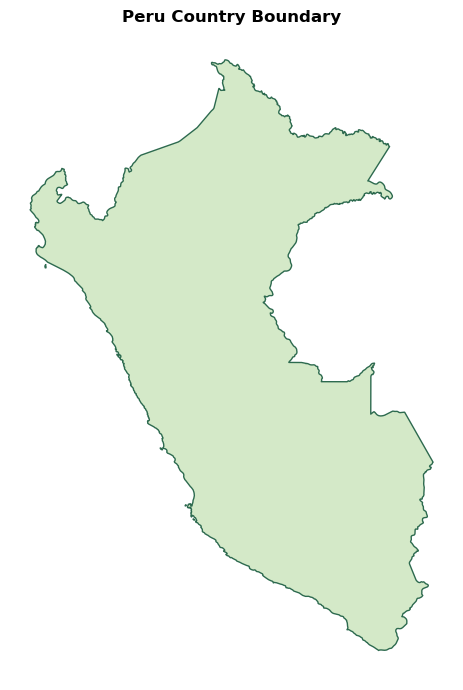

In [11]:
# Load Peru country boundary
peru_boundary = gpd.read_file(BOUNDARY_SHP).to_crs(epsg=4326)
print(f"Boundary CRS: {peru_boundary.crs}")

ax = peru_boundary.plot(figsize=(5, 7), color="#d4e9c8", edgecolor="#2d6a4f", linewidth=1)
ax.set_title("Peru Country Boundary", fontsize=12, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
clipped_by_year = {}

for year, gdf in yearly_gdfs.items():
    try:
        clipped = gpd.clip(gdf, peru_boundary)
        clipped = clipped[clipped.geometry.notnull() & clipped.geometry.is_valid]
        clipped_by_year[year] = clipped

        out_path = YEARLY_DIR / f"peru_burned_{year}.shp"
        clipped.to_file(out_path)
        print(f"  {year}: {len(clipped):,} polygons → {out_path.name}")
    except Exception as e:
        print(f"  {year}: clip failed — {e}")

print("\nPer-year export complete.")

  2001: 640 polygons → peru_burned_2001.shp
  2002: 1,884 polygons → peru_burned_2002.shp
  2003: 5,762 polygons → peru_burned_2003.shp
  2004: 2,904 polygons → peru_burned_2004.shp
  2005: 20,277 polygons → peru_burned_2005.shp
  2006: 3,982 polygons → peru_burned_2006.shp
  2007: 6,122 polygons → peru_burned_2007.shp
  2008: 3,122 polygons → peru_burned_2008.shp
  2009: 3,082 polygons → peru_burned_2009.shp
  2010: 10,258 polygons → peru_burned_2010.shp
  2011: 2,192 polygons → peru_burned_2011.shp
  2012: 6,128 polygons → peru_burned_2012.shp
  2013: 3,816 polygons → peru_burned_2013.shp
  2014: 3,430 polygons → peru_burned_2014.shp
  2015: 4,064 polygons → peru_burned_2015.shp
  2016: 8,074 polygons → peru_burned_2016.shp
  2017: 3,064 polygons → peru_burned_2017.shp
  2018: 3,890 polygons → peru_burned_2018.shp
  2019: 6,020 polygons → peru_burned_2019.shp
  2020: 7,944 polygons → peru_burned_2020.shp
  2021: 3,388 polygons → peru_burned_2021.shp
  2022: 9,950 polygons → peru_burn

## 8. Combine All Years & Export

In [13]:
all_years = gpd.GeoDataFrame(
    pd.concat(clipped_by_year.values(), ignore_index=True),
    crs="EPSG:4326"
)

out_combined = OUTPUT_DIR / "Peru_burned_area.shp"
all_years.to_file(out_combined)

print(f"Combined dataset: {len(all_years):,} burned area polygons")
print(f"Years covered   : {sorted(all_years.year.unique())}")
print(f"Saved to        : {out_combined}")

Combined dataset: 137,267 burned area polygons
Years covered   : [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Saved to        : ../outputs/Peru_burned_area.shp


## 9. Summary Visualisation — Burned Polygons per Year

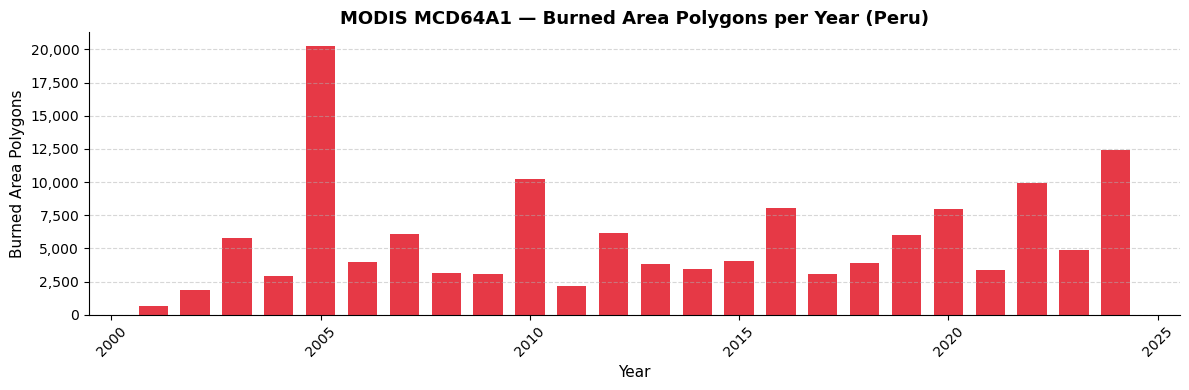

Plot saved.


In [14]:
annual_counts = all_years.groupby("year").size().reset_index(name="polygon_count")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(annual_counts.year, annual_counts.polygon_count, color="#e63946", width=0.7)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Burned Area Polygons", fontsize=11)
ax.set_title("MODIS MCD64A1 — Burned Area Polygons per Year (Peru)", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "burned_area_per_year.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

---

## Pipeline Summary

| Step | Output |
|------|--------|
| SFTP download | Raw `.tar.gz` archives (Win05 + Win06) |
| Extraction | Monthly shapefiles per tile |
| Merging | One GeoDataFrame per year (both tiles combined) |
| Clipping | Polygons trimmed to Peru boundary |
| Export | `Peru_burned_area.shp` + `yearly/*.shp` |

**Next step:** Use `02_fire_analysis.ipynb` to combine this burned area dataset with NASA FIRMS fire hotspots for a complete spatio-temporal fire analysis.